# Compare Monitors

Evaluates four monitoring methods (Anytime E-valuator, PAC E-valuator, CRC, UCB)
across two domains:

- **Factuality (MATH)**: Mistral-7B and Claude Haiku on MATH reasoning chains with signals from Qwen-PRM
- **Harmfulness**: Anthropic red-team data (`llama`) with safety signals from Llama guard and FineHarm (`scm-fineharm`) with signals from their SCM method

Each section: loads the signal data, computes series data for the e-valuator framework (saved as pickle), computes metrics over different calibration splits (saved as JSON), then plots
False Alarm Rate / Power / Detection Delay vs the tolerance level.

In [13]:
import sys
import os
import json
import pickle
import copy
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom

cwd = Path().resolve()
root = next(
    (p for p in [cwd] + list(cwd.parents) if (p / 'src' / 'evaluator').is_dir()),
    None,
)
if root is None:
    raise RuntimeError(f'Could not find repo root from {cwd}.')
sys.path.insert(0, str(root / 'src'))
sys.path.insert(0, str(cwd))   # for plotting_style.py in notebooks/
import evaluator as e_val
import plotting_style

In [14]:
# ── Method display names and colors ─────────────────────────────────────────
NAMES = {
    'crc_cond': 'CRC',
    'crc_hp':   'UCB',
    'anytime':  'E-valuator-anytime',
    'split':    'E-valuator-PAC',
}

COLORS = {
    'anytime':  'steelblue',
    'split':    'darkorange',
    'crc_cond': 'seagreen',
    'crc_hp':   'crimson',
}

METHODS = list(NAMES.keys())

# ── Evaluation hyperparameters ───────────────────────────────────────────────
ALPHAS    = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
DELTA     = 0.1    # confidence level for Split E-valuator
DELTA_CRC = 0.1    # confidence level for CRC high-probability bound
N_SPLITS  = 10     # random cal/test splits
CAL_FRAC  = 0.2    # fraction of problems used for calibration
BASE_SEED = 0

# ── Column names (must match the data) ──────────────────────────────────────
SCORE_COL   = 'judge_probability'
LABEL_COL   = 'solved'
PROBLEM_COL = 'uq_problem_idx'
STEP_COL    = 'num_steps'
TOKENS_COL  = 'generated_tokens'

# ── Plot layout ──────────────────────────────────────────────────────────────
COL_ORDER = ['fa', 'power', 'delay']
METRIC_LABELS = {
    'fa':    r'False Alarm Rate ($\downarrow$)',
    'power': r'Power ($\uparrow$)',
    'delay': r'Detection Delay ($\downarrow$)',
}

DS_NAMES = {
    'Mistral': 'Mistral-7B-Instruct',
    'Claude':  'Claude Haiku 4.5',
    'llama':   'Anthropic Red Teaming',
    'FineHarm': 'FineHarm',
}

In [15]:
def crc_class_cond(cal_df, test_df, alphas):
    cal_min      = cal_df.groupby(PROBLEM_COL)[SCORE_COL].min()
    cal_y        = cal_df.groupby(PROBLEM_COL)[LABEL_COL].max().astype(int)
    n_cal_solved = int((cal_y == 1).sum())
    solved_mins  = np.sort(cal_min[cal_y == 1].values)
    lam_grid     = np.linspace(0.0, 1.0, 10001)
    counts       = np.searchsorted(solved_mins, lam_grid, side='left')
    n1           = n_cal_solved + 1.0
    bound        = counts / n1 + 1.0 / n1
    lam_hat = {a: (float(lam_grid[bound <= a].max()) if (bound <= a).any() else None)
               for a in alphas}
    return _eval_threshold(test_df, lam_hat, alphas)


def _hb_pvalue_vec(counts, n, alpha):
    if n == 0:
        return np.ones(len(counts))
    r_hat = counts / n
    pvals = np.ones(len(counts))
    mask  = r_hat < alpha
    if not mask.any():
        return pvals
    r         = r_hat[mask]
    hoeffding = np.exp(-2 * n * (alpha - r) ** 2)
    k_alpha   = int(np.ceil(n * alpha))
    bentkus   = np.e * binom.sf(k_alpha - 1, n, r)
    pvals[mask] = np.minimum(hoeffding, bentkus)
    return pvals


def crc_class_cond_hp(cal_df, test_df, alphas, delta=DELTA_CRC):
    cal_min      = cal_df.groupby(PROBLEM_COL)[SCORE_COL].min()
    cal_y        = cal_df.groupby(PROBLEM_COL)[LABEL_COL].max().astype(int)
    n_cal_solved = int((cal_y == 1).sum())
    solved_mins  = np.sort(cal_min[cal_y == 1].values)
    lam_grid     = np.linspace(0.0, 1.0, 10001)
    counts       = np.searchsorted(solved_mins, lam_grid, side='left').astype(float)
    lam_hat = {}
    for a in alphas:
        pvals   = _hb_pvalue_vec(counts, n_cal_solved, a)
        valid   = pvals <= delta
        lam_hat[a] = float(lam_grid[valid].max()) if valid.any() else None
    return _eval_threshold(test_df, lam_hat, alphas)


def _eval_threshold(test_df, lam_hat, alphas):
    test_y        = test_df.groupby(PROBLEM_COL)[LABEL_COL].max().astype(int)
    solved_pids   = test_y[test_y == 1].index
    unsolved_pids = test_y[test_y == 0].index
    tokens_full   = test_df.groupby(PROBLEM_COL)[TOKENS_COL].sum()
    prob_min      = test_df.groupby(PROBLEM_COL)[SCORE_COL].min()
    unsolved_df   = (
        test_df[test_df[PROBLEM_COL].isin(unsolved_pids)]
        .sort_values([PROBLEM_COL, STEP_COL])
        .copy()
    )
    unsolved_df['_cum_tok'] = unsolved_df.groupby(PROBLEM_COL)[TOKENS_COL].cumsum()

    power, fa, frac = [], [], []
    for a in alphas:
        lam = lam_hat[a]
        if lam is None:
            power.append(0.0); fa.append(0.0); frac.append(0.0)
            continue
        fa.append(float((prob_min[solved_pids] < lam).mean()) if len(solved_pids) > 0 else 0.0)
        below = unsolved_df[unsolved_df[SCORE_COL] < lam]
        if below.empty:
            power.append(0.0); frac.append(0.0)
            continue
        first_cum = below.groupby(PROBLEM_COL)['_cum_tok'].first()
        power.append(len(first_cum) / max(len(unsolved_pids), 1))
        tf    = tokens_full.loc[first_cum.index]
        valid = tf > 0
        fracs = (tf[valid] - first_cum[valid]) / tf[valid]
        frac.append(float(fracs.mean()) if len(fracs) > 0 else 0.0)
    return {'power': power, 'fa': fa, 'frac': frac}


def one_split_eval(df, seed, alphas=ALPHAS, delta=DELTA, delta_crc=DELTA_CRC):
    unique_ids = df[PROBLEM_COL].unique()
    rng        = np.random.default_rng(seed)
    n_cal      = int(CAL_FRAC * len(unique_ids))
    cal_ids    = rng.choice(unique_ids, size=n_cal, replace=False)
    test_ids   = np.setdiff1d(unique_ids, cal_ids)
    cal_df     = df[df[PROBLEM_COL].isin(cal_ids)].reset_index(drop=True)
    test_df    = df[df[PROBLEM_COL].isin(test_ids)].reset_index(drop=True)

    ev = e_val.EValuator(
        model_type='logistic', mt_variant='both', alphas=alphas, delta=delta,
    )
    ev.fit(cal_df)
    test_df = ev.apply(test_df)

    problem_solved = test_df.groupby(PROBLEM_COL)[LABEL_COL].max().astype(int)
    solved_pids    = problem_solved[problem_solved == 1].index
    unsolved_pids  = problem_solved[problem_solved == 0].index
    tokens_full    = test_df.groupby(PROBLEM_COL)[TOKENS_COL].sum()
    unsolved_ev    = (
        test_df[test_df[PROBLEM_COL].isin(unsolved_pids)]
        .sort_values([PROBLEM_COL, STEP_COL])
        .copy()
    )
    unsolved_ev['_cum_tok'] = unsolved_ev.groupby(PROBLEM_COL)[TOKENS_COL].cumsum()

    results = {}
    for method_key, prefix in [('anytime', 'reject_anytime'), ('split', 'reject_split')]:
        power, fa, frac = [], [], []
        for a in alphas:
            base = str(a).replace('.', '_')
            col  = f'{prefix}_alpha_{base}'
            rej  = test_df.groupby(PROBLEM_COL)[col].max().astype(bool)
            fa.append(float(rej.loc[solved_pids].mean()) if len(solved_pids) > 0 else 0.0)
            power.append(float(rej.loc[unsolved_pids].mean()) if len(unsolved_pids) > 0 else 0.0)
            rej_rows = unsolved_ev[unsolved_ev[col]]
            if not rej_rows.empty:
                first_rej = rej_rows.groupby(PROBLEM_COL)['_cum_tok'].first()
                tf        = tokens_full.loc[first_rej.index]
                valid     = tf > 0
                fracs     = (tf[valid] - first_rej[valid]) / tf[valid]
                frac.append(float(fracs.mean()) if len(fracs) > 0 else 0.0)
            else:
                frac.append(0.0)
        results[method_key] = {'power': power, 'fa': fa, 'frac': frac}

    results['crc_cond'] = crc_class_cond(cal_df, test_df, alphas)
    results['crc_hp']   = crc_class_cond_hp(cal_df, test_df, alphas, delta=delta_crc)
    return results

In [16]:
import copy

def add_delay(all_results_math):
    result = copy.deepcopy(all_results_math)
    for runs in result.values():
        for run in runs:
            for metrics in run.values():
                metrics['delay'] = (1 - np.asarray(metrics['frac'])).tolist()
    return result

In [17]:
def add_delay(all_results):
    """Add 'delay' = 1 - frac to every split result (deep copy, non-destructive)."""
    result = copy.deepcopy(all_results)
    for runs in result.values():
        for run in runs:
            for metrics in run.values():
                metrics['delay'] = (1 - np.asarray(metrics['frac'])).tolist()
    return result


def aggregate(split_results, methods=METHODS):
    agg = {}
    for m in methods:
        if not any(m in r for r in split_results):
            continue
        stacked = {metric: np.array([r[m][metric] for r in split_results if m in r])
                   for metric in ('power', 'fa', 'frac', 'delay')}
        agg[m]  = {metric: {
            'mean': arr.mean(axis=0),
            'std':  arr.std(axis=0),
            'q10':  np.percentile(arr, 10, axis=0),
            'q90':  np.percentile(arr, 90, axis=0),
        } for metric, arr in stacked.items()}
    return agg


def plot_figure_transposed(agg_results, datasets_order, filename,
                           power_yli1m=None, power_ylim2=None,
                           dd_lim1=None, dd_lim2=None,
                           band='quantile'):
    """
    Transposed layout: metrics are rows, datasets are columns.

    band: 'std' for mean ± 1 std, 'quantile' for 10–90% band.
          'quantile' requires agg[method][metric] to contain 'q10' and 'q90'.
    """
    alphas_arr = np.array(ALPHAS)

    # Preserve user-specified order, drop datasets not in DS_NAMES
    valid_datasets = [ds for ds in datasets_order if ds in DS_NAMES]
    for ds in datasets_order:
        if ds not in DS_NAMES:
            print(f"Skipping {ds} (not in DS_NAMES)")

    n_cols = len(valid_datasets)
    n_rows = len(COL_ORDER)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(plotting_style.column_width, 1.3 * n_rows),
        sharex=True,
        squeeze=False,
    )

    n = len(alphas_arr)

    for col_idx, ds_name in enumerate(valid_datasets):
        agg = agg_results[ds_name]

        for row_idx, metric in enumerate(COL_ORDER):
            ax = axes[row_idx, col_idx]

            for method in METHODS:
                if method not in agg:
                    continue
                d    = agg[method][metric]
                mean = np.asarray(d['mean'])[:n]

                if band == 'quantile':
                    lo = np.asarray(d['q10'])[:n]
                    hi = np.asarray(d['q90'])[:n]
                else:  # 'std'
                    std = np.asarray(d['std'])[:n]
                    lo, hi = mean - std, mean + std

                ax.plot(alphas_arr, mean, marker='o',
                        color=COLORS[method], label=NAMES[method], alpha=1)
                ax.fill_between(alphas_arr, lo, hi,
                                alpha=0.2, color=COLORS[method])

            if metric == 'fa':
                ax.plot(alphas_arr, alphas_arr, '--', color='gray',
                        linewidth=1, label=r'$\hat{\mathcal{R}}^{I}(\hat{\lambda}) = \epsilon$')

            ax.set_xlim(alphas_arr[0] - 0.02, alphas_arr[-1] + 0.02)
            ax.set_ylim(0, 1)

            # Top row: dataset name as title
            if row_idx == 0:
                ax.set_title(DS_NAMES.get(ds_name, ds_name))
            # First column: metric label as ylabel
            if col_idx == 0:
                ax.set_ylabel(METRIC_LABELS[metric])

            # Per-(metric-row, dataset-col) ylim overrides
            if row_idx == 0:
                ax.set_ylim(0, 0.6)
            if row_idx == 1 and col_idx == 0 and power_yli1m is not None:
                ax.set_ylim(power_yli1m[0], power_yli1m[1])
            if row_idx == 1 and col_idx == 1 and power_ylim2 is not None:
                ax.set_ylim(power_ylim2[0], power_ylim2[1])
            if row_idx == 2 and col_idx == 0 and dd_lim1 is not None:
                ax.set_ylim(dd_lim1[0], dd_lim1[1])
            if row_idx == 2 and col_idx == 1 and dd_lim2 is not None:
                ax.set_ylim(dd_lim2[0], dd_lim2[1])

            if row_idx == n_rows - 1:
                ax.set_xlabel(r'$\epsilon$')
            if row_idx == 0 and col_idx == 1:
                ax.legend()

    plt.savefig(filename)
    plt.show()

---
## Factuality (MATH)

Two LLM generators (Mistral-7B-Instruct and Claude Haiku) solving MATH problems;
correctness judged by Qwen. `solved=1` means the final answer is correct.

**Output paths**
- Series cache: `output/factuality/monitor_performance/math_series.pkl`
- Split results: `output/factuality/monitor_performance/math_mistral_claude_seeds.json`

In [18]:
FACT_DATASETS = {
    'Mistral': '/home/mschirm/e-valuator/out/merged_Mistral-7B-Instruct-v0.3_qwen_all.csv',
    'Claude':  '/home/mschirm/e-valuator/out/merged_claude-haiku-4-5-20251001_qwen_all.csv',
}

FACT_SERIES_PATH  = '../output/factuality/monitor_performance/math_series.pkl'
FACT_RESULTS_PATH = '../output/factuality/monitor_performance/math_mistral_claude_seeds.json'

FACT_FORCE_RECOMPUTE = False  # set True to recompute from scratch

In [19]:
def _load_fact_series():
    raw = {}
    for ds_name, path in FACT_DATASETS.items():
        print(f'Loading {ds_name} ...')
        df = pd.read_csv(path)
        df = df[df['label_valid']].reset_index(drop=True)
        df['solved']    = 1 - df['error_final_o3']
        df['num_steps'] = df['step_idx'] + 1
        df = e_val.utils.add_judge_probability_series(df)
        raw[ds_name] = df
        solved_rate = df.groupby(PROBLEM_COL)[LABEL_COL].max().mean()
        print(f'  {ds_name}: {df.shape}, solved={solved_rate:.3f}')
    return raw


if not FACT_FORCE_RECOMPUTE and os.path.exists(FACT_RESULTS_PATH):
    with open(FACT_RESULTS_PATH) as f:
        fact_results = json.load(f)
    total_splits = sum(len(v) for v in fact_results.values())
    print(f'Loaded {total_splits} splits ({list(fact_results.keys())}) from {FACT_RESULTS_PATH}')

else:
    # Load series data (slow: ~2 min per dataset) or from cache
    if not FACT_FORCE_RECOMPUTE and os.path.exists(FACT_SERIES_PATH):
        with open(FACT_SERIES_PATH, 'rb') as f:
            raw_fact = pickle.load(f)
        print(f'Loaded series cache from {FACT_SERIES_PATH}')
    else:
        raw_fact = _load_fact_series()
        os.makedirs(os.path.dirname(os.path.abspath(FACT_SERIES_PATH)), exist_ok=True)
        with open(FACT_SERIES_PATH, 'wb') as f:
            pickle.dump(raw_fact, f)
        print(f'Series cache saved to {FACT_SERIES_PATH}')

    # Compute splits
    fact_results = {}
    for ds_name, df in raw_fact.items():
        print(f'\n=== {ds_name}: computing {N_SPLITS} splits ===')
        splits = []
        for i in range(N_SPLITS):
            res = one_split_eval(df, seed=BASE_SEED + i)
            splits.append({m: {k: list(map(float, v)) for k, v in mets.items()}
                           for m, mets in res.items()})
            print(f'  split {i + 1}/{N_SPLITS}')
        fact_results[ds_name] = splits

    os.makedirs(os.path.dirname(os.path.abspath(FACT_RESULTS_PATH)), exist_ok=True)
    with open(FACT_RESULTS_PATH, 'w') as f:
        json.dump(fact_results, f, indent=2)
    print(f'\nSaved to {FACT_RESULTS_PATH}')

Loaded 20 splits (['Mistral', 'Claude']) from ../output/factuality/monitor_performance/math_mistral_claude_seeds.json


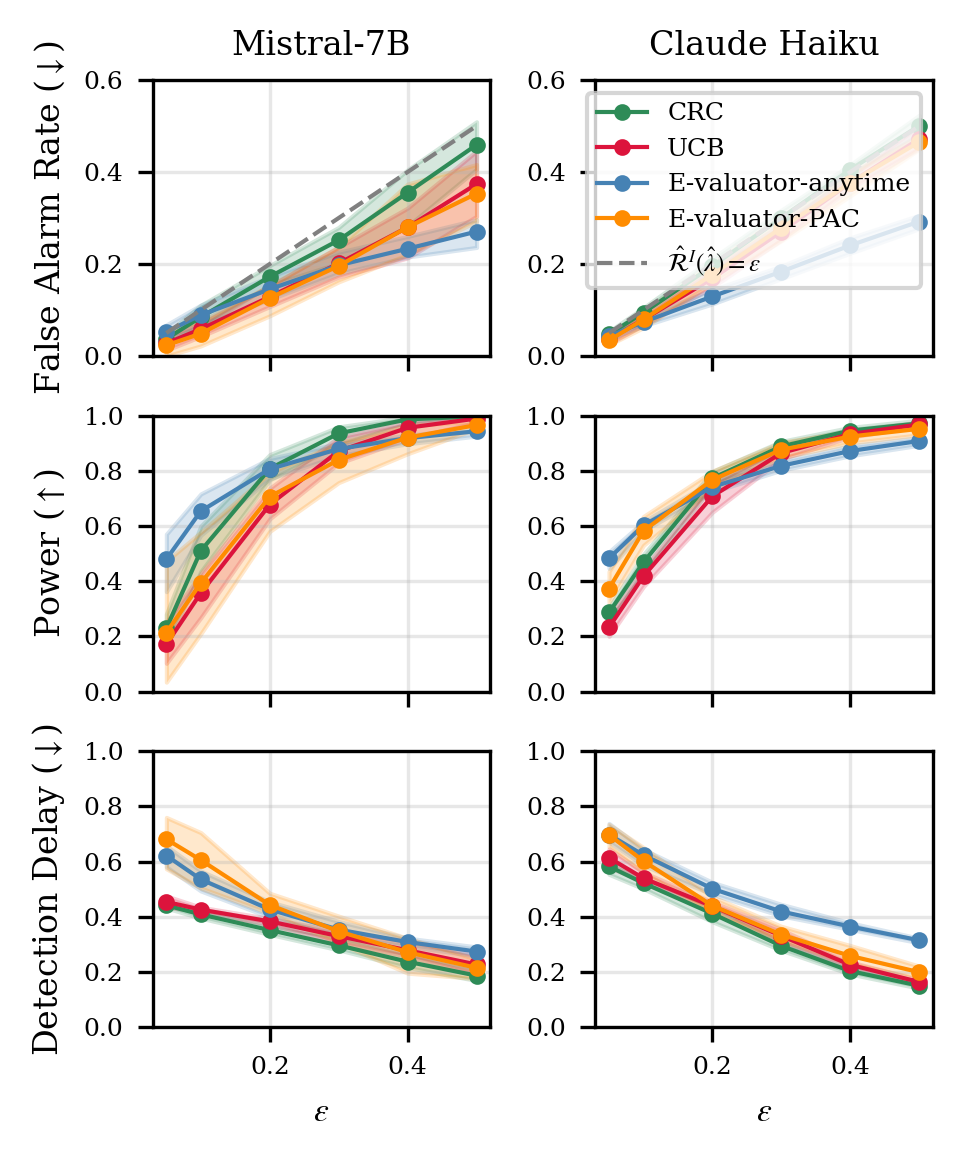

In [20]:
fact_results = add_delay(fact_results)
fact_agg = {ds: aggregate(splits) for ds, splits in fact_results.items()}

DS_NAMES = {
    'Mistral': 'Mistral-7B',
    'Claude':  'Claude Haiku',
}

plot_figure_transposed(
    fact_agg,
    datasets_order=list(FACT_DATASETS.keys()),
    filename='../plots/math_monitors_compared.png',
)

---
## Harmfulness

Two harm datasets:

| Key | Source | Description |
|---|---|---|
| `llama` | `output/harmfullness/anthropic-redteaming/llama.csv` | Anthropic red-team conversations scored by LLaMA Guard. `solved=1` (rating ≤ 2) means the conversation is *harmless*. |
| `scm_fineharm` | `scm-fineharm/test_predictions.npz` | FineHarm token-level predictions. `solved=1` means sequence is *safe*. |


In [21]:
# ── Source data ───────────────────────────────────────────────────────────────
HARM_LLAMA_CSV = '../output/harmfullness/anthropic-redteaming/llama.csv'
HARM_SCM_NPZ   = '../output/harmfullness/fineharm/test_predictions.npz'

# ── Series caches (judge_probability_series is slow to compute) ───────────────
HARM_LLAMA_SERIES_PATH = '../output/harmfullness/monitor_performance/llama_series.pkl'
HARM_SCM_SERIES_PATH   = '../output/harmfullness/monitor_performance/scm_series.pkl'

# ── Split results ─────────────────────────────────────────────────────────────
HARM_LLAMA_SEEDS_PATH = '../output/harmfullness/monitor_performance/llama_seeds.json'
HARM_SCM_SEEDS_PATH   = '../output/harmfullness/monitor_performance/scm_seeds.json'

HARM_FORCE_RECOMPUTE = False
SCM_CHUNK_SIZE = 32  # tokens per monitoring step

In [22]:
def _load_llama_data():
    print(f'Loading LLaMA data from {HARM_LLAMA_CSV} ...')
    df = pd.read_csv(HARM_LLAMA_CSV, low_memory=False)
    df['num_steps']         = df['turn']
    df['judge_probability'] = df['safe_prob']
    df['solved']            = (df['rating'] <= 2).astype(int)
    df['uq_problem_idx']    = df['conversation_id']
    df['generated_tokens']  = 100  # equal-weight steps
    df                      = df[df['model_type']=='context distillation']
    df = e_val.utils.add_judge_probability_series(df)
    lengths = df['judge_probability_series'].apply(len)
    invalid = df.loc[lengths != df['num_steps'], PROBLEM_COL].unique()
    if len(invalid):
        print(f'  Removing {len(invalid)} conversations with mismatched series length.')
        df = df[~df[PROBLEM_COL].isin(invalid)]
    solved_rate = df.groupby(PROBLEM_COL)[LABEL_COL].max().mean()
    print(f'  llama: {df.shape}, n_conversations={df[PROBLEM_COL].nunique()}, solved={solved_rate:.3f}')
    return df


def _load_scm_data():
    print(f'Loading SCM FineHarm from {HARM_SCM_NPZ} ...')
    d  = np.load(HARM_SCM_NPZ, allow_pickle=True)
    tp = d['token_predictions']   # (N, T, 2) logits
    tl = d['token_labels']        # (N, T)    {-100, 0, 1}
    sl = d['sequence_labels']     # (N,)      {0, 1}

    # Numerically stable softmax → P(safe) = P(class=0)
    m_ = tp.max(axis=-1, keepdims=True)
    e_ = np.exp(tp - m_)
    p_safe = (e_ / e_.sum(axis=-1, keepdims=True))[..., 0]  # (N, T)

    rows = []
    for i in range(tp.shape[0]):
        valid = tl[i] != -100
        if not valid.any():
            continue
        scores   = p_safe[i, valid]
        L        = scores.shape[0]
        n_chunks = int(np.ceil(L / SCM_CHUNK_SIZE))
        for k in range(n_chunks):
            lo, hi = k * SCM_CHUNK_SIZE, min(L, (k + 1) * SCM_CHUNK_SIZE)
            rows.append({
                'uq_problem_idx':    int(i),
                'num_steps':         k + 1,
                'judge_probability': float(scores[lo:hi].min()),
                'solved':            int(1 - sl[i]),
                'generated_tokens':  int(hi - lo),
            })

    df = pd.DataFrame(rows)
    df = e_val.utils.add_judge_probability_series(df)
    lengths     = df['judge_probability_series'].apply(len)
    invalid_ids = df.loc[lengths != df['num_steps'], PROBLEM_COL].unique()
    if len(invalid_ids):
        print(f'  Removing {len(invalid_ids)} sequences with mismatched series length.')
        df = df[~df[PROBLEM_COL].isin(invalid_ids)]
    solved_rate = df.groupby(PROBLEM_COL)[LABEL_COL].max().mean()
    print(f'  scm: {df.shape}, n_sequences={df[PROBLEM_COL].nunique()}, solved={solved_rate:.3f}')
    return df

In [23]:
os.makedirs('../output/harmfullness/monitor_performance', exist_ok=True)

# ── FineHarm (SCM) ────────────────────────────────────────────────────────────
if not HARM_FORCE_RECOMPUTE and os.path.exists(HARM_SCM_SERIES_PATH):
    with open(HARM_SCM_SERIES_PATH, 'rb') as f:
        scm_df = pickle.load(f)
    print(f'Loaded SCM series from cache: {scm_df.shape}')
else:
    scm_df = _load_scm_data()
    with open(HARM_SCM_SERIES_PATH, 'wb') as f:
        pickle.dump(scm_df, f)
    print(f'Saved SCM series to {HARM_SCM_SERIES_PATH}')

if not HARM_FORCE_RECOMPUTE and os.path.exists(HARM_SCM_SEEDS_PATH):
    with open(HARM_SCM_SEEDS_PATH) as f:
        scm_splits = json.load(f)
    print(f'Loaded {len(scm_splits)} SCM splits from cache')
else:
    scm_splits = []
    for i in range(N_SPLITS):
        res = one_split_eval(scm_df, seed=BASE_SEED + i)
        scm_splits.append({m: {k: list(map(float, v)) for k, v in mets.items()}
                           for m, mets in res.items()})
        print(f'  SCM split {i + 1}/{N_SPLITS}')
    with open(HARM_SCM_SEEDS_PATH, 'w') as f:
        json.dump(scm_splits, f, indent=2)
    print(f'Saved SCM splits to {HARM_SCM_SEEDS_PATH}')

# ── Llama (Anthropic red team) ────────────────────────────────────────────────
if not HARM_FORCE_RECOMPUTE and os.path.exists(HARM_LLAMA_SERIES_PATH):
    with open(HARM_LLAMA_SERIES_PATH, 'rb') as f:
        llama_df = pickle.load(f)
    print(f'Loaded Llama series from cache: {llama_df.shape}')
else:
    llama_df = _load_llama_data()
    with open(HARM_LLAMA_SERIES_PATH, 'wb') as f:
        pickle.dump(llama_df, f)
    print(f'Saved Llama series to {HARM_LLAMA_SERIES_PATH}')

if not HARM_FORCE_RECOMPUTE and os.path.exists(HARM_LLAMA_SEEDS_PATH):
    with open(HARM_LLAMA_SEEDS_PATH) as f:
        llama_splits = json.load(f)
    print(f'Loaded {len(llama_splits)} Llama splits from cache')
else:
    llama_splits = []
    for i in range(N_SPLITS):
        res = one_split_eval(llama_df, seed=BASE_SEED + i)
        llama_splits.append({m: {k: list(map(float, v)) for k, v in mets.items()}
                             for m, mets in res.items()})
        print(f'  Llama split {i + 1}/{N_SPLITS}')
        with open(HARM_LLAMA_SEEDS_PATH, 'w') as f:  # incremental save
            json.dump(llama_splits, f, indent=2)
    print(f'Saved Llama splits to {HARM_LLAMA_SEEDS_PATH}')

Loaded SCM series from cache: (33078, 6)
Loaded 10 SCM splits from cache
Loaded Llama series from cache: (153199, 32)
Loaded 10 Llama splits from cache


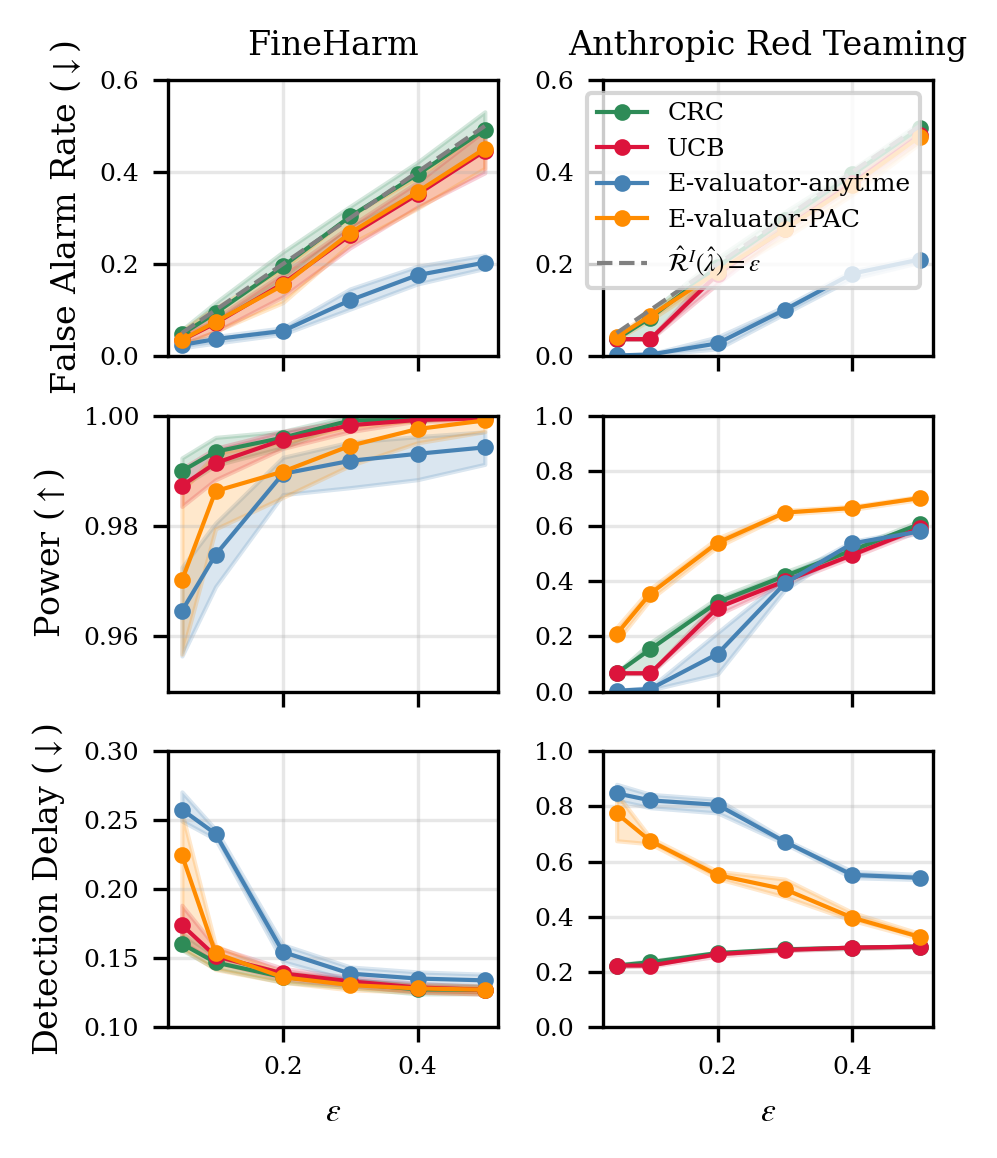

In [24]:
harm_results = {
    'scm_fineharm': scm_splits,
    'llama':        llama_splits,
}
harm_results = add_delay(harm_results)
harm_agg = {ds: aggregate(splits) for ds, splits in harm_results.items()}

DS_NAMES = {
    'scm_fineharm': 'FineHarm',
    'llama':        'Anthropic Red Teaming',
}

plot_figure_transposed(
    harm_agg,
    datasets_order=['scm_fineharm', 'llama'],
    filename='../plots/harm_monitors_compared.png',
    power_yli1m=(0.95, 1.0),
    dd_lim1=(0.1, 0.3),
)